# Progress 2: Three-Model Comparison for Network Intrusion Detection

Notebook ini disusun untuk kebutuhan progres 2 dengan fokus pada:

1. Menentukan 3 metode klasifikasi
2. Menjelaskan alasan pemilihan metode
3. Menjelaskan konsep dasar metode
4. Menentukan parameter non-default
5. Menyajikan hasil sementara perbandingan metode

Metode yang dibandingkan:

- Decision Tree
- Random Forest
- XGBoost

## 1. Business Understanding

Permasalahan yang diangkat adalah deteksi intrusi jaringan, yaitu mengidentifikasi apakah sebuah koneksi jaringan termasuk **normal** atau **anomaly**. Karena output yang ingin diprediksi berupa kategori, maka tugas analitik pada project ini termasuk **klasifikasi biner**.

Tujuan utama progres ini adalah membandingkan performa tiga model klasifikasi berbasis tree, yaitu model dasar (**Decision Tree**), model ensemble bagging (**Random Forest**), dan model ensemble boosting (**XGBoost**).

## 2. Pemilihan Metode

Ketiga metode dipilih dengan alasan berikut:

- **Decision Tree** digunakan sebagai baseline sederhana berbasis tree yang mudah diinterpretasikan.
- **Random Forest** digunakan sebagai pengembangan Decision Tree dengan pendekatan bagging agar prediksi lebih stabil.
- **XGBoost** digunakan sebagai model boosting berbasis tree yang dikenal kuat untuk data tabular.

Dengan susunan ini, perbandingan menjadi sistematis: **single tree -> bagging ensemble -> boosting ensemble**.

In [1]:
import pandas as pd

method_summary = pd.DataFrame([
    {
        "method": "Decision Tree",
        "reason_for_selection": "Baseline tree-based classifier that is simple and easy to interpret.",
        "basic_concept": "Builds one tree by splitting data based on the best feature at each node until a class decision is reached.",
    },
    {
        "method": "Random Forest",
        "reason_for_selection": "Bagging-based ensemble of many decision trees for more stable and robust predictions.",
        "basic_concept": "Builds many trees from bootstrap samples and combines predictions with majority voting.",
    },
    {
        "method": "XGBoost",
        "reason_for_selection": "Boosting-based tree ensemble with strong performance on tabular data.",
        "basic_concept": "Builds trees sequentially, where each new tree tries to correct errors from previous trees.",
    },
])

display(method_summary)

,method,reason_for_selection,basic_concept
0,Decision Tree,Baseline tree-based classifier that is simple ...,Builds one tree by splitting data based on the...
1,Random Forest,Bagging-based ensemble of many decision trees ...,Builds many trees from bootstrap samples and c...
2,XGBoost,Boosting-based tree ensemble with strong perfo...,"Builds trees sequentially, where each new tree..."


## 3. Data Understanding

Dataset yang digunakan adalah `Train_data.csv` dari Kaggle Network Intrusion Detection. File ini memiliki label target `class`, sehingga dapat digunakan untuk training dan evaluasi model.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [3]:
DATA_PATH = Path("../data/raw/Train_data.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (25192, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
print("Data types and non-null counts:")
df.info()

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
display(df["class"].value_counts())

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-nul

duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64


Duplicate rows: 0

Class distribution:


class
normal     13449
anomaly    11743
Name: count, dtype: int64

### Exploratory Data Analysis (EDA)

EDA dilakukan untuk melihat distribusi target, statistik deskriptif, dan hubungan awal antara fitur dan target.

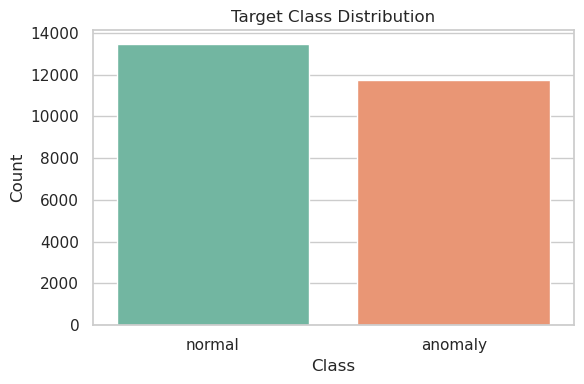

,count,mean,std,min,25%,50%,75%,max
duration,25192.0,305.054104,2.686556e+03,0.0,0.00,0.00,0.00,42862.0
src_bytes,25192.0,24330.628215,2.410805e+06,0.0,0.00,44.00,279.00,381709090.0
dst_bytes,25192.0,3491.847174,8.883072e+04,0.0,0.00,0.00,530.25,5151385.0
land,25192.0,0.000079,8.909946e-03,0.0,0.00,0.00,0.00,1.0
wrong_fragment,25192.0,0.023738,2.602208e-01,0.0,0.00,0.00,0.00,3.0
urgent,25192.0,0.000040,6.300408e-03,0.0,0.00,0.00,0.00,1.0
hot,25192.0,0.198039,2.154202e+00,0.0,0.00,0.00,0.00,77.0
num_failed_logins,25192.0,0.001191,4.541818e-02,0.0,0.00,0.00,0.00,4.0
logged_in,25192.0,0.394768,4.888105e-01,0.0,0.00,0.00,1.00,1.0
num_compromised,25192.0,0.227850,1.041735e+01,0.0,0.00,0.00,0.00,884.0


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", hue="class", palette="Set2", legend=False)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(df.describe().T)

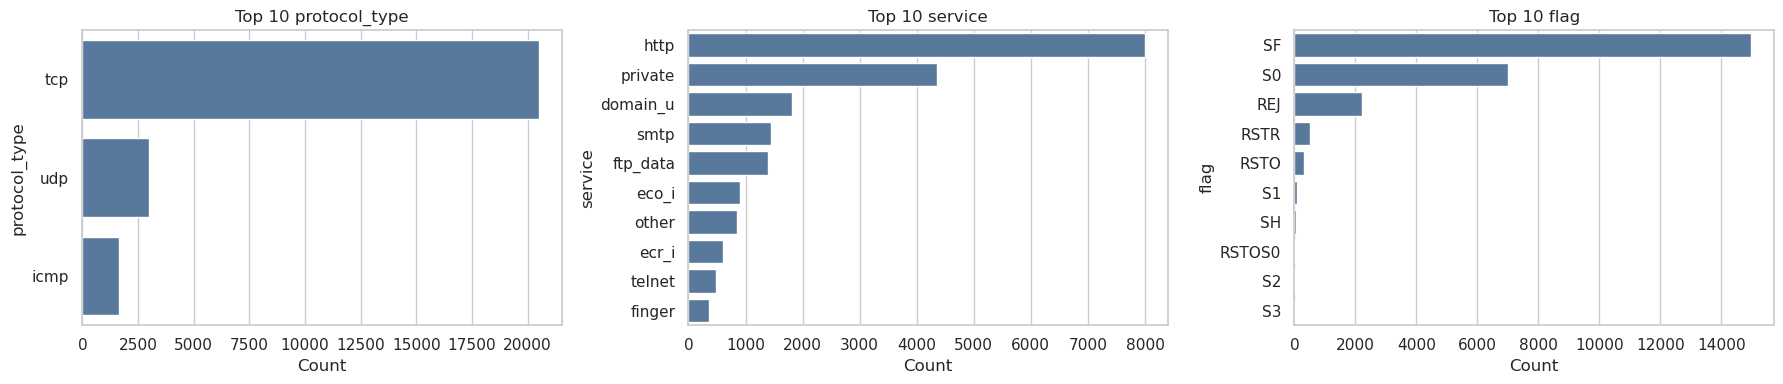

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["protocol_type", "service", "flag"]):
    top_values = df[col].value_counts().head(10)
    sns.barplot(x=top_values.values, y=top_values.index, ax=ax, color="#4C78A8")
    ax.set_title(f"Top 10 {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

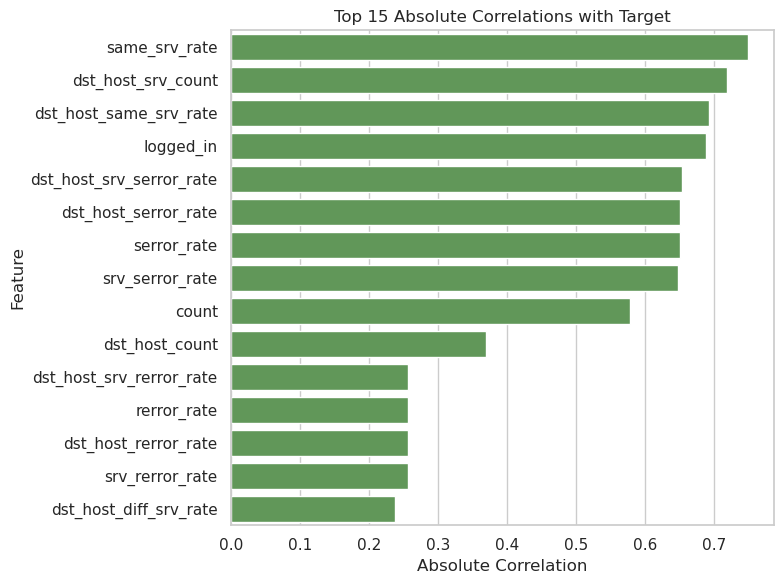

,absolute_correlation
same_srv_rate,0.749237
dst_host_srv_count,0.719292
dst_host_same_srv_rate,0.692212
logged_in,0.688084
dst_host_srv_serror_rate,0.653759
dst_host_serror_rate,0.651050
serror_rate,0.649952
srv_serror_rate,0.647817
count,0.578790
dst_host_count,0.368828


In [7]:
df_eda = df.copy()
df_eda["target"] = (df_eda["class"] != "normal").astype(int)

corr_with_target = (
    df_eda.select_dtypes(include=["int64", "float64"])
    .corr()["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, color="#59A14F")
plt.title("Top 15 Absolute Correlations with Target")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(corr_with_target.to_frame("absolute_correlation"))

## 4. Data Preparation

Tahap preparation meliputi:

1. Mengubah target menjadi biner (`normal = 0`, `anomaly = 1`)
2. Memisahkan fitur `X` dan target `y`
3. Mengidentifikasi fitur kategorikal dan numerik
4. Membagi data menjadi train-test
5. Mengubah fitur kategorikal dengan One-Hot Encoding

In [8]:
df_model = df.copy()
df_model["target"] = (df_model["class"] != "normal").astype(int)

X = df_model.drop(columns=["class", "target"])
y = df_model["target"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Number of numeric features:", len(numeric_features))
print("X shape:", X.shape)
print("y shape:", y.shape)
display(y.value_counts().rename(index={0: "normal", 1: "anomaly"}))

Categorical features: ['protocol_type', 'service', 'flag']
Number of numeric features: 38
X shape: (25192, 41)
y shape: (25192,)


target
normal     13449
anomaly    11743
Name: count, dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (17634, 41)
Testing set: (7558, 41)


## 5. Non-Default Parameters

Sesuai arahan progres 2, model tidak dijalankan dengan parameter full default. Parameter ditentukan untuk mengontrol kompleksitas model, menjaga stabilitas, dan menyesuaikan karakteristik klasifikasi biner pada dataset ini.

In [10]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

parameter_summary = pd.DataFrame([
    {
        "method": "Decision Tree",
        "parameters": "criterion='entropy', max_depth=10, min_samples_split=10, min_samples_leaf=4, class_weight='balanced', random_state=42",
    },
    {
        "method": "Random Forest",
        "parameters": "n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2, max_features='log2', class_weight='balanced', random_state=42, n_jobs=-1",
    },
    {
        "method": "XGBoost",
        "parameters": f"n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight={scale_pos_weight:.4f}, objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1",
    },
])

display(parameter_summary)

,method,parameters
0,Decision Tree,"criterion='entropy', max_depth=10, min_samples..."
1,Random Forest,"n_estimators=200, max_depth=15, min_samples_sp..."
2,XGBoost,"n_estimators=200, max_depth=6, learning_rate=0..."


## 6. Modeling

Model dilatih menggunakan preprocessing yang sama agar perbandingan adil.

In [11]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            DecisionTreeClassifier(
                criterion="entropy",
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="log2",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

for name, model in [
    ("Decision Tree", dt_pipeline),
    ("Random Forest", rf_pipeline),
    ("XGBoost", xgb_pipeline),
]:
    model.fit(X_train, y_train)
    print(f"Training finished: {name}")

Training finished: Decision Tree
Training finished: Random Forest
Training finished: XGBoost


## 7. Model Evaluation

Evaluasi dilakukan dengan beberapa metrik performa klasifikasi: accuracy, precision, recall/sensitivity, specificity, F1-score, ROC-AUC, serta confusion matrix.

In [12]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall_sensitivity": recall_score(y_test, y_pred),
        "specificity": specificity,
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "false_positive": fp,
        "false_negative": fn,
    }

    print(f"=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"]))
    print()
    return result

results = [
    evaluate_model("Decision Tree", dt_pipeline, X_test, y_test),
    evaluate_model("Random Forest", rf_pipeline, X_test, y_test),
    evaluate_model("XGBoost", xgb_pipeline, X_test, y_test),
]

results_df = pd.DataFrame(results)
display(results_df.sort_values("f1_score", ascending=False).reset_index(drop=True))

=== Decision Tree ===
Confusion Matrix:
[[4016   19]
 [  21 3502]]

Classification Report:
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      4035
     anomaly       0.99      0.99      0.99      3523

    accuracy                           0.99      7558
   macro avg       0.99      0.99      0.99      7558
weighted avg       0.99      0.99      0.99      7558


=== Random Forest ===
Confusion Matrix:
[[4028    7]
 [  31 3492]]

Classification Report:
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      4035
     anomaly       1.00      0.99      0.99      3523

    accuracy                           0.99      7558
   macro avg       1.00      0.99      0.99      7558
weighted avg       0.99      0.99      0.99      7558


=== XGBoost ===
Confusion Matrix:
[[4030    5]
 [  19 3504]]

Classification Report:
              precision    recall  f1-score   support

      normal       1.0

,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,false_positive,false_negative
0,XGBoost,0.996825,0.998575,0.994607,0.998761,0.996587,0.999943,5,19
1,Random Forest,0.994972,0.997999,0.991201,0.998265,0.994588,0.999824,7,31
2,Decision Tree,0.994708,0.994604,0.994039,0.995291,0.994321,0.997217,19,21


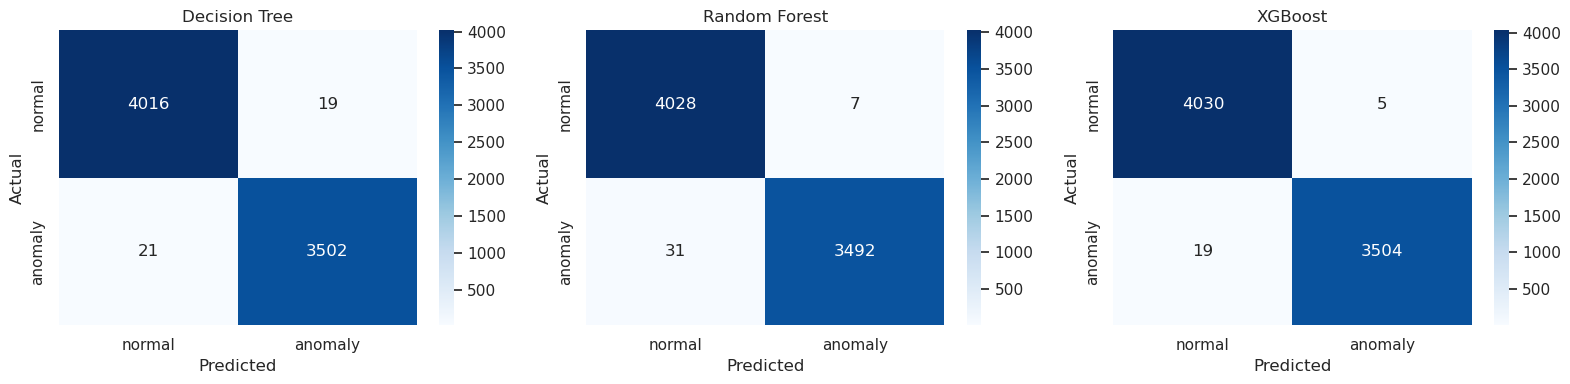

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name, model in zip(
    axes,
    ["Decision Tree", "Random Forest", "XGBoost"],
    [dt_pipeline, rf_pipeline, xgb_pipeline],
):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "anomaly"],
        yticklabels=["normal", "anomaly"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

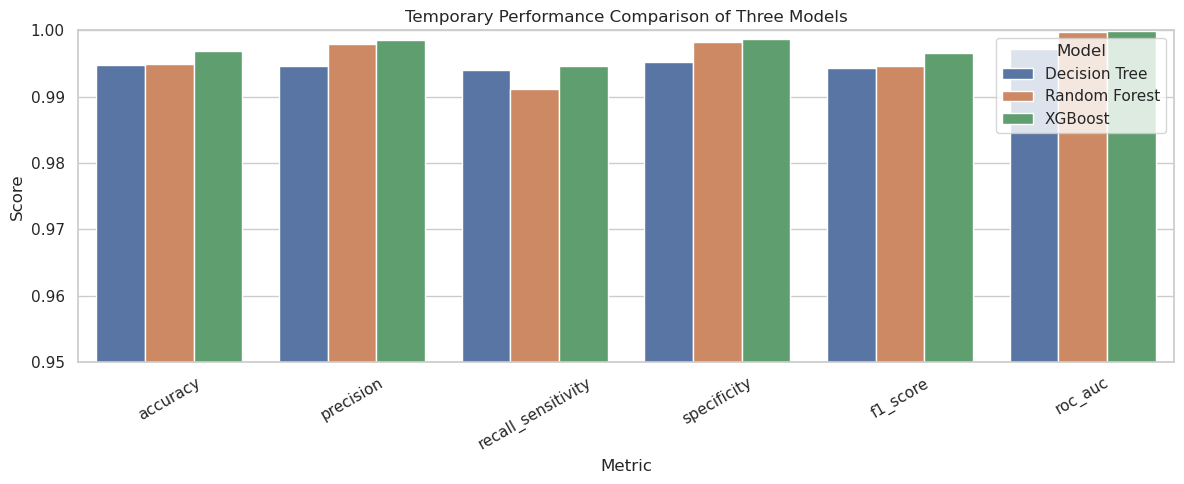

In [14]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
]

results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted, x="metric", y="score", hue="model")
plt.ylim(0.95, 1.0)
plt.title("Temporary Performance Comparison of Three Models")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 8. Feature Importance and Interpretive Notes

Feature importance ditampilkan untuk model tree-based yang menyediakan interpretasi langsung terhadap kontribusi fitur.

,feature,importance
81,src_bytes,0.119622
82,dst_bytes,0.071598
105,same_srv_rate,0.062470
109,dst_host_srv_count,0.061394
78,flag_SF,0.048383
88,logged_in,0.046008
111,dst_host_diff_srv_rate,0.045933
110,dst_host_same_srv_rate,0.043964
99,count,0.042267
106,diff_srv_rate,0.039374


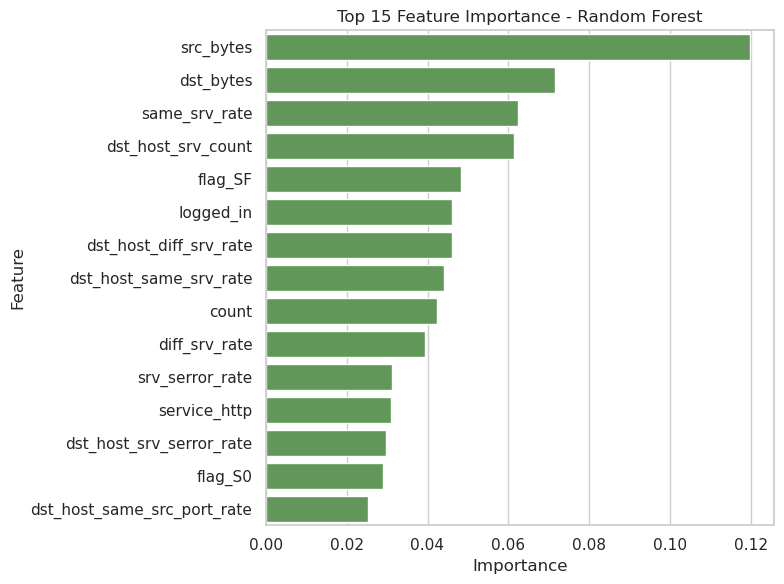

In [15]:
preprocessor = rf_pipeline.named_steps["preprocess"]
rf_model = rf_pipeline.named_steps["model"]

cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([cat_feature_names, numeric_features])

rf_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_importances.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importances.head(15), x="importance", y="feature", color="#59A14F")
plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 9. Temporary Conclusion

Bagian ini digunakan untuk menuliskan hasil sementara progres 2 setelah tiga model dibandingkan.

Poin yang perlu diamati:

- Apakah ensemble model memberikan performa lebih tinggi daripada Decision Tree tunggal?
- Model mana yang memiliki recall lebih baik untuk mendeteksi anomaly?
- Model mana yang menghasilkan false negative paling rendah?
- Apakah parameter non-default yang dipilih membantu menjaga keseimbangan performa model?

Setelah notebook dijalankan, simpulan sementara dapat ditulis berdasarkan tabel `results_df` dan confusion matrix.